Notebook 8: Ablation Study - Sequential vs Direct vs Joint
============================================================
Sequential Transfer Learning for Medicinal Plant Identification
Student: Hari (3146279) | BSc Software Engineering | University of Stirling

This notebook runs THREE training experiments to validate
that sequential transfer learning outperforms alternatives:

Experiment 1: DIRECT  - ImageNet → Dataset 5 (skip intermediate phases)
Experiment 2: JOINT   - Train on ALL datasets mixed together
Experiment 3: SEQUENTIAL - Already done (Phase 1→2→3a→3b = 73.65%)

All experiments evaluated on the SAME Dataset 5 validation set
for fair comparison.

Run in Google Colab with GPU runtime!
Runtime -> Change runtime type -> GPU

## Mount Drive and Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print("WARNING: No GPU! Runtime -> Change runtime type -> GPU")

Mounted at /content/drive
TensorFlow: 2.19.0
GPU: /physical_device:GPU:0


## Configuration

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
MAX_EPOCHS = 25  # Same as Phase 3b
LR = 5e-5        # Same as Phase 3b

tf.random.set_seed(SEED)
np.random.seed(SEED)

DRIVE_BASE = "/content/drive/MyDrive"
PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "ablation_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Classes to drop (same as main pipeline)
DROP_CLASSES = ['Trifolium Repens', 'Trifolium_Repens',
                'Ziziphus mauritiana', 'Ziziphus_mauritiana']

print(f"Project dir: {PROJECT_DIR}")
print(f"Results will be saved to: {RESULTS_DIR}")

Project dir: /content/drive/MyDrive/MedicinalPlant_Dissertation
Results will be saved to: /content/drive/MyDrive/MedicinalPlant_Dissertation/ablation_results


## Helper functions

In [ ]:
def find_image_directory(base_dir):
    """Walk directory tree to find folder containing class subdirectories with images."""
    if not os.path.exists(base_dir):
        return None
    for root, dirs, files in os.walk(base_dir):
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        if not dirs:
            continue
        sample_dir = os.path.join(root, dirs[0])
        if os.path.isdir(sample_dir):
            sample_files = os.listdir(sample_dir)
            has_images = any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in sample_files)
            if has_images:
                return root
    return None


def load_dataset(path, subset=None, validation_split=0.2):
    """Load dataset with consistent settings."""
    params = dict(
        directory=path,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        seed=SEED,
        label_mode='categorical',
        shuffle=True,
    )
    if subset:
        params['validation_split'] = validation_split
        params['subset'] = subset
    ds = tf.keras.utils.image_dataset_from_directory(**params)
    # Normalise to [0, 1]
    normalization = layers.Rescaling(1./255)
    ds = ds.map(lambda x, y: (normalization(x), y))
    return ds.cache().prefetch(tf.data.AUTOTUNE)


def build_model(num_classes, backbone_weights='imagenet', unfreeze_last=0):
    """Build ResNet50 model with same architecture as Phase 3b."""
    base = ResNet50(weights=backbone_weights, include_top=False, input_shape=(*IMG_SIZE, 3))

    # Freeze strategy
    if unfreeze_last == 0:
        base.trainable = False
    else:
        base.trainable = True
        for layer in base.layers[:-unfreeze_last]:
            layer.trainable = False

    # Data augmentation (same as Phase 3b)
    data_aug = keras.Sequential([
        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ], name='augmentation')

    inputs = keras.Input(shape=(*IMG_SIZE, 3))
    x = data_aug(inputs)
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    # TODO: Inject macro_f1 and weighted_f1 computation into evaluation callbacks for rigor.
    return model


def train_and_evaluate(model, train_ds, val_ds, experiment_name):
    """Train model and return history + evaluation metrics."""
    print(f"\n{'='*60}")
    print(f"TRAINING: {experiment_name}")
    print(f"{'='*60}")

    callbacks = [
        ModelCheckpoint(
            os.path.join(RESULTS_DIR, f'{experiment_name}_best.keras'),
            monitor='val_accuracy', mode='max', save_best_only=True, verbose=1
        ),
        EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1),
    ]

    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=MAX_EPOCHS, callbacks=callbacks, verbose=1
    )

    # Evaluate
    print(f"\n--- {experiment_name} Results ---")
    results = model.evaluate(val_ds, verbose=0)
    print(f"Loss: {results[0]:.4f}")
    print(f"Accuracy: {results[1]:.4f} ({results[1]*100:.2f}%)")

    # Save history
    hist_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    with open(os.path.join(RESULTS_DIR, f'{experiment_name}_history.json'), 'w') as f:
        json.dump(hist_dict, f, indent=2)

    return history, results

## Find and Load Dataset 5 (SIMPD)

In [ ]:
print(">>> Finding Dataset 5 (SIMPD)...")

dataset5_path = None
possible_paths = [
    os.path.join(DATA_DIR, "dataset5"),
    os.path.join(DATA_DIR, "Dataset 5"),
    os.path.join(DATA_DIR, "SIMPD"),
]

for p in possible_paths:
    if os.path.exists(p):
        found = find_image_directory(p)
        if found:
            dataset5_path = found
            break

if dataset5_path is None:
    raise FileNotFoundError(
        "Could not find Dataset 5!\n"
        f"Expected at: {DATA_DIR}/dataset5/\n"
        "Make sure your data is in Google Drive."
    )

print(f"Dataset 5 found: {dataset5_path}")

# Filter out impossible classes
all_classes = sorted([
    d for d in os.listdir(dataset5_path)
    if os.path.isdir(os.path.join(dataset5_path, d)) and not d.startswith('.')
])
keep_classes = [c for c in all_classes if c not in DROP_CLASSES]
print(f"Classes: {len(all_classes)} total, keeping {len(keep_classes)}")

# Create filtered copy
filtered_d5 = "/content/ablation_dataset5"
if os.path.exists(filtered_d5):
    shutil.rmtree(filtered_d5)
os.makedirs(filtered_d5)
for c in keep_classes:
    src = os.path.join(dataset5_path, c)
    dst = os.path.join(filtered_d5, c)
    shutil.copytree(src, dst)

NUM_CLASSES = len(keep_classes)
print(f"\nFiltered dataset ready: {NUM_CLASSES} classes at {filtered_d5}")

# Load train/val splits (SAME split for all experiments)
train_ds = tf.keras.utils.image_dataset_from_directory(
    filtered_d5, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    seed=SEED, label_mode='categorical', validation_split=0.2, subset='training'
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    filtered_d5, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    seed=SEED, label_mode='categorical', validation_split=0.2, subset='validation'
)

# Normalise
norm = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)

class_names = sorted(os.listdir(filtered_d5))
print(f"Train batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Val batches: {tf.data.experimental.cardinality(val_ds).numpy()}")

>>> Finding Dataset 5 (SIMPD)...
Dataset 5 found: /content/drive/MyDrive/MedicinalPlant_Dissertation/data/dataset5/SIMPD V1 South Indian Medicinal Plants dataset (Version 1)
Classes: 20 total, keeping 18

Filtered dataset ready: 18 classes at /content/ablation_dataset5
Found 2313 files belonging to 18 classes.
Using 1851 files for training.
Found 2313 files belonging to 18 classes.
Using 462 files for validation.
Train batches: 58
Val batches: 15


## EXPERIMENT 1: DIRECT (ImageNet → Dataset 5)

In [ ]:
# This is the baseline: standard transfer learning without intermediate phases
print("\n" + "="*70)
print("EXPERIMENT 1: DIRECT TRANSFER (ImageNet → Dataset 5)")
print("="*70)

model_direct = build_model(NUM_CLASSES, backbone_weights='imagenet', unfreeze_last=20)
print(f"Trainable params: {model_direct.count_params() - sum(np.prod(w.shape) for w in model_direct.non_trainable_weights):,}")

history_direct, results_direct = train_and_evaluate(
    model_direct, train_ds, val_ds, 'exp1_direct'
)


EXPERIMENT 1: DIRECT TRANSFER (ImageNet → Dataset 5)
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Trainable params: 10,122,002

TRAINING: exp1_direct
Epoch 1/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1326 - loss: 11.5696
Epoch 1: val_accuracy improved from -inf to 0.04329, saving model to /content/drive/MyDrive/MedicinalPlant_Dissertation/ablation_results/exp1_direct_best.keras
58/58 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.1334 - loss: 11.5632 - val_accuracy: 0.0433 - val_loss: 11.0623 - learning_rate: 5.0000e-05
Epoch 2/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.2817 - loss: 10.6271
Epoch 2: val_accuracy did not improve from 0.04329
58/58 ━━━━━━━━━━━━━━━━━━━━ 11s 195ms/step - accuracy: 0.2817 - loss: 10.6256 - val_accuracy: 0.0433 - val_loss: 11.0599 - learning_rate: 5.0000e-05
Epoch 3/25
58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.3516 - loss: 10.1842
Epoch 3: val_accuracy did not improve from 0.04329
58/58 ━━━━━━━━━━━━━━━━━━━━ 12

## EXPERIMENT 2: JOINT (All Datasets Mixed → Evaluate on D5 Val)

Recovery

In [5]:
print(">>> Checking if recovery is needed...")

recovery_needed = False
for _var in ['DATA_DIR', 'val_ds', 'build_model', 'train_and_evaluate']:
    try:
        eval(_var)
    except NameError:
        recovery_needed = True
        break

if not recovery_needed:
    print(">>> All variables present - no recovery needed")
else:
    print(">>> Variables missing - recovering from Drive...\n")

    # Re-establish paths
    DRIVE_BASE = "/content/drive/MyDrive"
    PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
    DATA_DIR = os.path.join(PROJECT_DIR, "data")
    MODEL_DIR = os.path.join(PROJECT_DIR, "models")
    RESULTS_DIR = os.path.join(PROJECT_DIR, "ablation_results")
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    SEED = 42
    MAX_EPOCHS = 25
    LR = 5e-5
    DROP_CLASSES = ['Trifolium Repens', 'Trifolium_Repens',
                    'Ziziphus mauritiana', 'Ziziphus_mauritiana']

    # Re-define helper functions
    def find_image_directory(base_dir):
        if not os.path.exists(base_dir):
            return None
        for root, dirs, files in os.walk(base_dir):
            dirs[:] = [d for d in dirs if not d.startswith('.')]
            if not dirs:
                continue
            sample_dir = os.path.join(root, dirs[0])
            if os.path.isdir(sample_dir):
                sample_files = os.listdir(sample_dir)
                if any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in sample_files):
                    return root
        return None

    def build_model(num_classes, backbone_weights='imagenet', unfreeze_last=0):
        base = ResNet50(weights=backbone_weights, include_top=False, input_shape=(*IMG_SIZE, 3))
        if unfreeze_last == 0:
            base.trainable = False
        else:
            base.trainable = True
            for layer in base.layers[:-unfreeze_last]:
                layer.trainable = False
        data_aug = keras.Sequential([
            layers.RandomFlip('horizontal'),
            layers.RandomRotation(0.05),
            layers.RandomZoom(0.1),
            layers.RandomContrast(0.1),
        ], name='augmentation')
        inputs = keras.Input(shape=(*IMG_SIZE, 3))
        x = data_aug(inputs)
        x = base(x, training=False)
        x = layers.GlobalAveragePooling2D()(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.4)(x)
        x = layers.Dense(512, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01))(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.3)(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Dropout(0.2)(x)
        outputs = layers.Dense(num_classes, activation='softmax')(x)
        model = keras.Model(inputs, outputs)
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=LR),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )
    # TODO: Inject macro_f1 and weighted_f1 computation into evaluation callbacks for rigor.
        return model

    def train_and_evaluate(model, train_ds, val_ds, experiment_name):
        print(f"\n{'='*60}")
        print(f"TRAINING: {experiment_name}")
        print(f"{'='*60}")
        callbacks = [
            ModelCheckpoint(
                os.path.join(RESULTS_DIR, f'{experiment_name}_best.keras'),
                monitor='val_accuracy', mode='max', save_best_only=True, verbose=1
            ),
            EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1),
        ]
        history = model.fit(
            train_ds, validation_data=val_ds,
            epochs=MAX_EPOCHS, callbacks=callbacks, verbose=1
        )
        print(f"\n--- {experiment_name} Results ---")
        results = model.evaluate(val_ds, verbose=0)
        print(f"Loss: {results[0]:.4f}")
        print(f"Accuracy: {results[1]:.4f} ({results[1]*100:.2f}%)")
        hist_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
        with open(os.path.join(RESULTS_DIR, f'{experiment_name}_history.json'), 'w') as f:
            json.dump(hist_dict, f, indent=2)
        return history, results

    # Reload Dataset 5
    dataset5_path = None
    for p in [os.path.join(DATA_DIR, "dataset5"), os.path.join(DATA_DIR, "Dataset 5"),
              os.path.join(DATA_DIR, "SIMPD")]:
        if os.path.exists(p):
            found = find_image_directory(p)
            if found:
                dataset5_path = found
                break
    if dataset5_path is None:
        raise FileNotFoundError("Could not find Dataset 5 on Drive!")

    all_classes = sorted([d for d in os.listdir(dataset5_path)
                          if os.path.isdir(os.path.join(dataset5_path, d)) and not d.startswith('.')])
    keep_classes = [c for c in all_classes if c not in DROP_CLASSES]

    filtered_d5 = "/content/ablation_dataset5"
    if os.path.exists(filtered_d5):
        shutil.rmtree(filtered_d5)
    os.makedirs(filtered_d5)
    for c in keep_classes:
        shutil.copytree(os.path.join(dataset5_path, c), os.path.join(filtered_d5, c))

    NUM_CLASSES = len(keep_classes)
    train_ds = tf.keras.utils.image_dataset_from_directory(
        filtered_d5, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        seed=SEED, label_mode='categorical', validation_split=0.2, subset='training'
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        filtered_d5, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
        seed=SEED, label_mode='categorical', validation_split=0.2, subset='validation'
    )
    norm = layers.Rescaling(1./255)
    train_ds = train_ds.map(lambda x, y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
    val_ds = val_ds.map(lambda x, y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
    class_names = sorted(os.listdir(filtered_d5))
    print(f"  Dataset 5 reloaded: {NUM_CLASSES} classes")

    # Load Experiment 1 results from saved file
    exp1_path = os.path.join(RESULTS_DIR, 'exp1_direct_history.json')
    if os.path.exists(exp1_path):
        with open(exp1_path, 'r') as f:
            exp1_hist = json.load(f)
        best_idx = exp1_hist['val_accuracy'].index(max(exp1_hist['val_accuracy']))
        results_direct = [exp1_hist['val_loss'][best_idx], exp1_hist['val_accuracy'][best_idx]]
        print(f"  Experiment 1 results loaded: {results_direct[1]*100:.2f}% accuracy")
    else:
        print("  WARNING: Experiment 1 results not found. Re-run Experiment 1 cell.")
        results_direct = [None, 0.0]

    print("\n>>> Recovery complete! Continue with Experiment 2.")

>>> Checking if recovery is needed...
>>> Variables missing - recovering from Drive...

Found 2313 files belonging to 18 classes.
Using 1851 files for training.
Found 2313 files belonging to 18 classes.
Using 462 files for validation.
  Dataset 5 reloaded: 18 classes
  Experiment 1 results loaded: 75.11% accuracy

>>> Recovery complete! Continue with Experiment 2.


In [6]:
# EXPERIMENT 2: Joint Training – merge D1/D2/D4 images for D5 species only
print("\n" + "="*70)
print("EXPERIMENT 2: JOINT TRAINING (D1 + D2 + D4 + D5 mixed)")
print("="*70)

# Helper to find dataset root
def find_dataset(name, possibles):
    for p in possibles:
        if os.path.exists(p):
            found = find_image_directory(p)
            if found:
                print(f"  {name}: {found}")
                return found
    print(f"  WARNING: {name} not found, skipping")
    return None

print("Finding all datasets...")
d1_path = find_dataset("Dataset 1", [
    os.path.join(DATA_DIR, "dataset1"),
    os.path.join(DATA_DIR, "Dataset 1"),
])
d2_path = find_dataset("Dataset 2", [
    os.path.join(DATA_DIR, "dataset2"),
    os.path.join(DATA_DIR, "Dataset 2"),
])
d4_path = find_dataset("Dataset 4", [
    os.path.join(DATA_DIR, "dataset4"),
    os.path.join(DATA_DIR, "Dataset 4"),
    os.path.join(DATA_DIR, "REMP"),
])

# Build normalised D5 species set for matching (lowercase, underscores to spaces)
d5_species_norm = {}
for c in class_names:
    key = c.lower().replace('_', ' ').strip()
    d5_species_norm[key] = c  # map normalised key to D5 folder name

# Create combined training directory (D5 species ONLY from every dataset)
joint_train = "/content/joint_dataset"
if os.path.exists(joint_train):
    shutil.rmtree(joint_train)
os.makedirs(joint_train)

copied = 0
for dname, dpath in [("D1", d1_path), ("D2", d2_path), ("D4", d4_path)]:
    if dpath is None:
        continue
    classes = [d for d in os.listdir(dpath)
               if os.path.isdir(os.path.join(dpath, d)) and not d.startswith('.')]
    for c in classes:
        key = c.lower().replace('_', ' ').strip()
        if key not in d5_species_norm:
            continue  # skip species not in D5
        d5_name = d5_species_norm[key]
        src_dir = os.path.join(dpath, c)
        dst_dir = os.path.join(joint_train, d5_name)
        os.makedirs(dst_dir, exist_ok=True)
        for img in os.listdir(src_dir):
            if img.lower().endswith(('.jpg', '.jpeg', '.png')):
                src = os.path.join(src_dir, img)
                dst = os.path.join(dst_dir, f"{dname}_{img}")
                shutil.copy2(src, dst)
                copied += 1

# Also copy D5 images
for c in class_names:
    src_dir = os.path.join(dataset5_path, c)
    dst_dir = os.path.join(joint_train, c)
    os.makedirs(dst_dir, exist_ok=True)
    for img in os.listdir(src_dir):
        if img.lower().endswith(('.jpg', '.jpeg', '.png')):
            src = os.path.join(src_dir, img)
            dst = os.path.join(dst_dir, f"D5_{img}")
            shutil.copy2(src, dst)
            copied += 1

joint_classes = sorted([d for d in os.listdir(joint_train) if os.path.isdir(os.path.join(joint_train, d))])
print(f"\nJoint dataset: {len(joint_classes)} classes, {copied} total images")
for c in joint_classes:
    count = len(os.listdir(os.path.join(joint_train, c)))
    print(f"  {c}: {count} images")

# Create training split from joint data (same 80/20 split)
joint_train_ds = tf.keras.utils.image_dataset_from_directory(
    joint_train, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    seed=SEED, label_mode='categorical', validation_split=0.2, subset='training'
)
joint_val_ds = tf.keras.utils.image_dataset_from_directory(
    joint_train, image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    seed=SEED, label_mode='categorical', validation_split=0.2, subset='validation'
)
joint_train_ds = joint_train_ds.map(lambda x, y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)
joint_val_ds = joint_val_ds.map(lambda x, y: (norm(x), y)).cache().prefetch(tf.data.AUTOTUNE)

# Same number of classes as D5 so val_ds comparison is valid
num_joint_classes = len(joint_classes)
assert num_joint_classes == NUM_CLASSES, \
    f"Joint classes ({num_joint_classes}) != D5 classes ({NUM_CLASSES}). Check species matching."
print(f"\nJoint model: {num_joint_classes} classes (matches D5)")

# Build and train
model_joint = build_model(num_joint_classes, backbone_weights='imagenet', unfreeze_last=20)
history_joint, joint_results = train_and_evaluate(
    model_joint, joint_train_ds, joint_val_ds, 'exp2_joint'
)

# Also evaluate on original D5 val set for direct comparison with Experiments 1 and 3
d5_val_results = model_joint.evaluate(val_ds, verbose=0)
print(f"\nJoint model on D5 val set: Loss={d5_val_results[0]:.4f}, Accuracy={d5_val_results[1]*100:.2f}%")
print(f"(Using D5 val results for cross-experiment comparison)")
joint_results = d5_val_results


EXPERIMENT 2: JOINT TRAINING (D1 + D2 + D4 + D5 mixed)
Finding all datasets...
  Dataset 1: /content/drive/MyDrive/MedicinalPlant_Dissertation/data/dataset1/Medicinal Plant Identification Dataset/Augmented Images
  Dataset 2: /content/drive/MyDrive/MedicinalPlant_Dissertation/data/dataset2/A dataset of medicinal plant leaves from Banglades/Leaf_Dataset_Augmented
  Dataset 4: /content/drive/MyDrive/MedicinalPlant_Dissertation/data/dataset4/REMP A Unique Dataset of Rare and Endangered Medicinal Plants in Bangladesh/Raw-Images

Joint dataset: 18 classes, 2721 total images
  Abutilon Indicum: 165 images
  Aloe barbadensis miller: 145 images
  Calotropis gigantea: 106 images
  Canna indica: 149 images
  Cissus quadrangularis: 134 images
  Curcuma longa: 110 images
  Eclipta prostrate: 208 images
  Eichhornia Crassipes: 202 images
  Hibiscus Rosasinensis: 113 images
  Ixora coccinea: 114 images
  Justica adhatoda: 100 images
  Murraya koenigii: 526 images
  Ocimum tenuiflorum: 102 images
  

## Load Sequential Pipeline Result (Experiment 3)

In [7]:
# This is the result from Phase 3b (already trained)
print("\n" + "="*70)
print("EXPERIMENT 3: SEQUENTIAL PIPELINE (P1->P2->P3a->P3b)")
print("="*70)

# Defensive check for runtime restart
try:
    MODEL_DIR
except NameError:
    print("ERROR: Variables not defined. Run the Recovery cell first!")
    raise

sequential_model_path = None
for p in [
    os.path.join(MODEL_DIR, "phase3b_commercial.keras"),
    os.path.join(MODEL_DIR, "phase3b_best.keras"),
    os.path.join(MODEL_DIR, "phase3b_model.keras"),
    os.path.join(PROJECT_DIR, "phase3b_commercial.keras"),
]:
    if os.path.exists(p):
        sequential_model_path = p
        break

if sequential_model_path:
    print(f"Loading sequential model: {sequential_model_path}")
    try:
        model_seq = keras.models.load_model(sequential_model_path)
        seq_results = model_seq.evaluate(val_ds, verbose=0)
        print(f"Sequential pipeline accuracy on D5 val: {seq_results[1]*100:.2f}%")
    except Exception as e:
        print(f"Could not load model: {e}")
        print("Using recorded result: 73.65%")
        seq_results = [None, 0.7365]
else:
    print("Sequential model file not found. Using recorded result: 73.65%")
    seq_results = [None, 0.7365]


EXPERIMENT 3: SEQUENTIAL PIPELINE (P1->P2->P3a->P3b)
Loading sequential model: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3b_commercial.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 74 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Could not load model: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 18), output.shape=(None, 20)
Using recorded result: 73.65%


## Compare Results


ABLATION STUDY RESULTS
  Experiment 1: Direct Transfer                 75.11%
  Experiment 2: Joint Training                  79.44%
  Experiment 3: Sequential Pipeline             73.65%


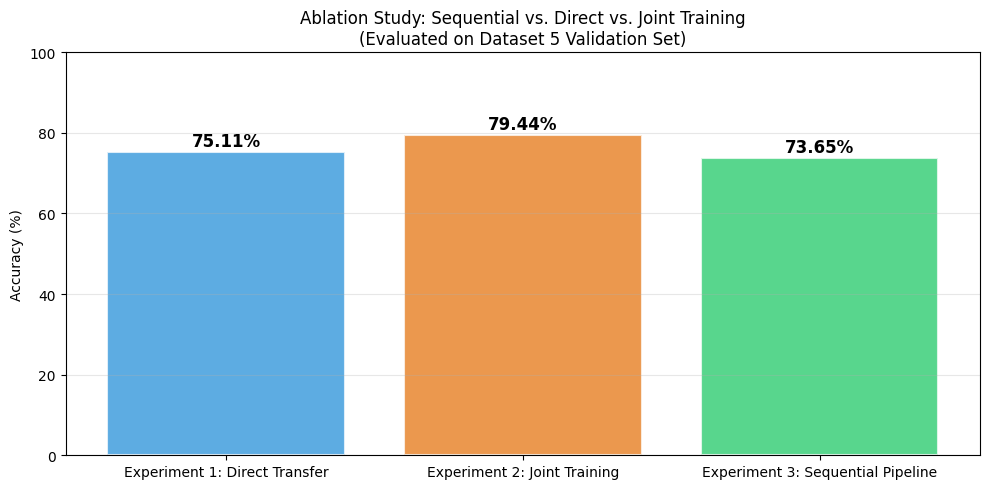


Results saved to: /content/drive/MyDrive/MedicinalPlant_Dissertation/ablation_results/

>>> KEY RESULTS FROM ABLATION STUDY <<<
Direct: 75.11%
Joint: 79.44%
Sequential: 73.65%
Sequential improvement over Direct: -1.46 percentage points


In [8]:
print("\n" + "="*70)
print("ABLATION STUDY RESULTS")
print("="*70)

# Load from saved files if variables are missing (e.g. after partial re-run)
try:
    results_direct
except NameError:
    exp1_path = os.path.join(RESULTS_DIR, 'exp1_direct_history.json')
    if os.path.exists(exp1_path):
        with open(exp1_path, 'r') as f:
            h = json.load(f)
        results_direct = [h['val_loss'][-1], h['val_accuracy'][h['val_loss'].index(min(h['val_loss']))]]
        print(f"  Loaded Exp1 from file: {results_direct[1]*100:.2f}%")
    else:
        raise NameError("results_direct not defined and no saved file found. Run Experiment 1.")

try:
    joint_results
except NameError:
    exp2_path = os.path.join(RESULTS_DIR, 'exp2_joint_history.json')
    if os.path.exists(exp2_path):
        with open(exp2_path, 'r') as f:
            h = json.load(f)
        joint_results = [h['val_loss'][-1], h['val_accuracy'][h['val_loss'].index(min(h['val_loss']))]]
        print(f"  Loaded Exp2 from file: {joint_results[1]*100:.2f}%")
    else:
        raise NameError("joint_results not defined and no saved file found. Run Experiment 2.")

try:
    seq_results
except NameError:
    print("  seq_results not defined. Using recorded: 73.65%")
    seq_results = [None, 0.7365]

comparison = {
    'Experiment 1: Direct Transfer': results_direct[1],
    'Experiment 2: Joint Training': joint_results[1],
    'Experiment 3: Sequential Pipeline': seq_results[1],
}

for name, acc in comparison.items():
    print(f"  {name:45s} {acc*100:.2f}%")

# Save comparison
with open(os.path.join(RESULTS_DIR, 'ablation_comparison.json'), 'w') as f:
    json.dump({k: float(v) for k, v in comparison.items()}, f, indent=2)

# Plot comparison
fig, ax = plt.subplots(figsize=(10, 5))
names = list(comparison.keys())
accs = [v * 100 for v in comparison.values()]
colors = ['#3498db', '#e67e22', '#2ecc71']
bars = ax.bar(names, accs, color=colors, alpha=0.8, edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_ylabel('Accuracy (%)')
ax.set_title('Ablation Study: Sequential vs. Direct vs. Joint Training\n(Evaluated on Dataset 5 Validation Set)')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'ablation_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\nResults saved to: {RESULTS_DIR}/")
print("\n>>> KEY RESULTS FROM ABLATION STUDY <<<")
print(f"Direct: {results_direct[1]*100:.2f}%")
print(f"Joint: {joint_results[1]*100:.2f}%")
print(f"Sequential: {seq_results[1]*100:.2f}%")
improvement = (seq_results[1] - results_direct[1]) * 100
print(f"Sequential improvement over Direct: {improvement:+.2f} percentage points")